In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from tensorflow.keras.applications.vgg16 import VGG16
from keras.layers import Dense, GlobalAveragePooling2D
from keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.vgg16 import preprocess_input
import seaborn as sns

In [3]:
# Define constants
TUMOR_TRAIN_DIR = "./content/Training/Tumor"
resize_width = 224
resize_height = 224

In [4]:
train_data_gen = ImageDataGenerator(validation_split=0.2, preprocessing_function=preprocess_input)

# Training and validation generators
train_generator = train_data_gen.flow_from_directory(TUMOR_TRAIN_DIR,
                                                     target_size=(resize_width, resize_height),
                                                     color_mode='rgb',
                                                     batch_size=32,
                                                     shuffle=True,
                                                     subset='training')

validation_generator = train_data_gen.flow_from_directory(TUMOR_TRAIN_DIR,
                                                          target_size=(resize_width, resize_height),
                                                          color_mode='rgb',
                                                          batch_size=32,
                                                          shuffle=False,
                                                          subset='validation')


Found 248 images belonging to 2 classes.
Found 62 images belonging to 2 classes.


In [5]:
# Class mapping
labels = train_generator.class_indices
class_mapping = dict((v, k) for k, v in labels.items())
print("Class Mapping:", class_mapping)

Class Mapping: {0: 'no', 1: 'yes'}


In [6]:
class_mapping

{0: 'no', 1: 'yes'}

./content/Training/Tumor\no
./content/Training/Tumor\yes


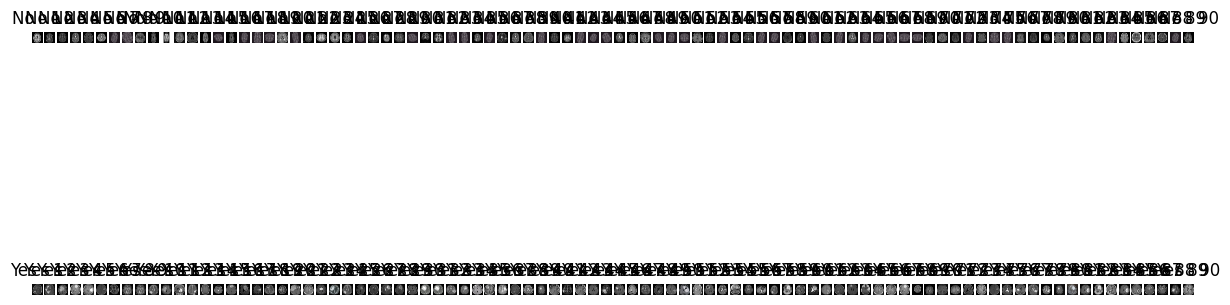

In [7]:
def plot_random_images(dataset_path, class_labels=('no', 'yes'), num_images=90):
    plt.figure(figsize=(15, 6))

    for class_label in class_labels:
        class_path = os.path.join(dataset_path, class_label)
        print(class_path)
        image_files = os.listdir(class_path)
        random_images = random.sample(image_files, num_images)

        for i, image_file in enumerate(random_images, start=1):
            plt.subplot(len(class_labels), num_images, (class_labels.index(class_label) * num_images) + i)

            img_path = os.path.join(class_path, image_file)
            img = mpimg.imread(img_path)
            img = cv2.resize(img, (224, 224))
            plt.imshow(img, cmap='gray')

            plt.axis('off')
            plt.title(f'{class_label.capitalize()} - {i}')

    plt.show()

# Plot random images to verify dataset
dataset_path = TUMOR_TRAIN_DIR
plot_random_images(dataset_path)


In [8]:
# Load VGG16 as the base model
img_rows, img_cols = 224, 224
vgg = VGG16(weights="imagenet",
            include_top=False,
            input_shape=(img_rows, img_cols, 3))

# Freeze layers of VGG16
for layer in vgg.layers:
    layer.trainable = False

In [9]:
# Structure the model
def structure_model(bottom_model, num_classes):
    top_model = bottom_model.output
    top_model = GlobalAveragePooling2D()(top_model)
    top_model = Dense(1024, activation='relu')(top_model)
    top_model = Dense(1024, activation='relu')(top_model)
    top_model = Dense(512, activation='relu')(top_model)
    top_model = Dense(num_classes, activation='softmax')(top_model)  # Use softmax for multi-class classification
    return top_model

In [10]:
num_classes = 2  # Number of classes in the dataset
model_head = structure_model(vgg, num_classes)
model = Model(inputs=vgg.input, outputs=model_head)

# Print model summary
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 16,815,426 (64.15 MB)

 Trainable params: 2,100,738 (8.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


In [11]:
# Compile model
opt = Adam(learning_rate=0.0001)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])


In [12]:
# Define ModelCheckpoint callback
train_cb = ModelCheckpoint('model/best_model.keras', save_best_only=True)

# Train model
history = model.fit(train_generator, validation_data=validation_generator, callbacks=[train_cb], epochs=5)

Epoch 1/5


C:\Users\vaibh\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.7242 - loss: 0.5809 - val_accuracy: 0.6935 - val_loss: 0.6934
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.9054 - loss: 0.2590 - val_accuracy: 0.8387 - val_loss: 0.4031
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.9699 - loss: 0.0893 - val_accuracy: 0.8387 - val_loss: 0.4970
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.9892 - loss: 0.0515 - val_accuracy: 0.7903 - val_loss: 0.7146
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.9917 - loss: 0.0363 - val_accuracy: 0.8387 - val_loss: 0.4409


2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
              precision    recall  f1-score   support

           0       0.92      0.74      0.82        31
           1       0.78      0.94      0.85        31

    accuracy                           0.84        62
   macro avg       0.85      0.84      0.84        62
weighted avg       0.85      0.84      0.84        62



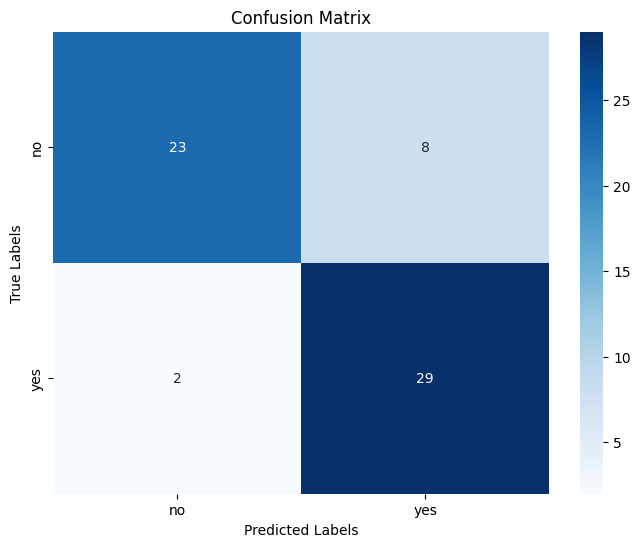

In [13]:
# Evaluate the model on validation data
predictions = model.predict(validation_generator)

# Convert true labels to the corresponding class
true_labels = validation_generator.classes
predicted_labels = np.argmax(predictions, axis=1)

# Print classification report and confusion matrix
cr = classification_report(true_labels, predicted_labels)
print(cr)

conf_matrix = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_mapping.values(), yticklabels=class_mapping.values())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

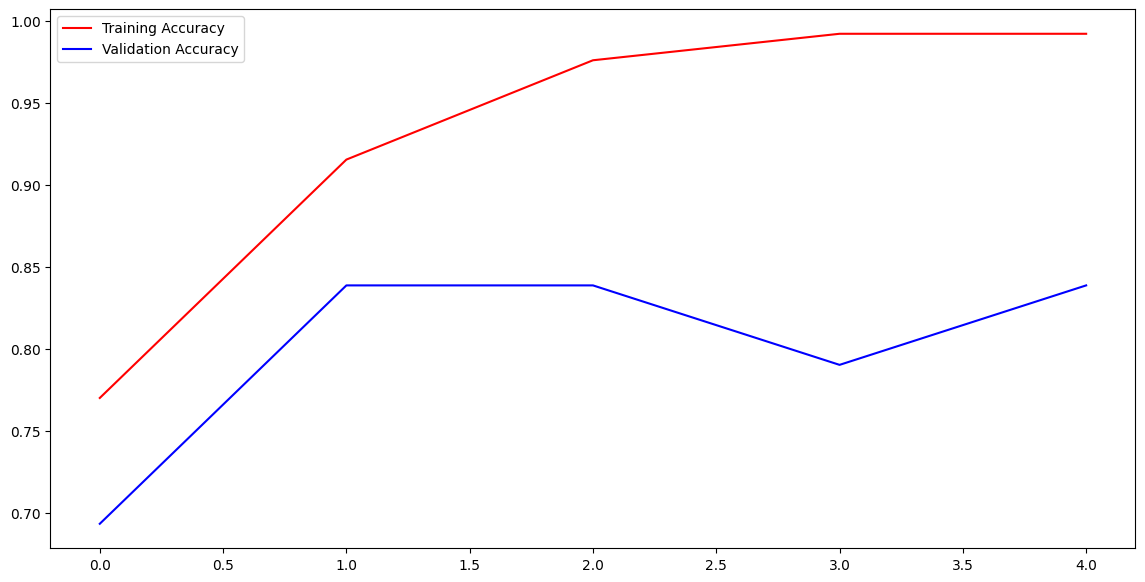

In [14]:
# Plot training and validation accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs, acc, 'r', label="Training Accuracy")
plt.plot(epochs, val_acc, 'b', label="Validation Accuracy")
plt.legend(loc='upper left')
plt.show()

In [18]:
# Predict on a sample image
imgToRead = "./content/Training/Stroke/yes/2 (1).jpg"
img = cv2.imread(imgToRead)
img = cv2.resize(img, (resize_width, resize_height), cv2.INTER_LANCZOS4)
img_array = np.array(img)

In [19]:
# Preprocess input image before prediction
img_array = preprocess_input(img_array)

# Reshape the image for prediction
img_array = img_array.reshape(1, resize_width, resize_height, 3)

# Make prediction
a = model.predict(img_array)
print("Raw Prediction Output:", a)

# Get the predicted class index
indices = np.argmax(a)
print(f"Predicted Class: {class_mapping[indices]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Raw Prediction Output: [[0.93114024 0.06885977]]
Predicted Class: no


In [20]:
a=model.predict(img_array)
print(a)
indices = a.argmax()
indices

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
[[0.93114024 0.06885977]]


0